In [1]:
import pandas as pd

# Use a raw string to avoid backslash escape warnings on Windows paths.
df = pd.read_csv(r"G:\My Drive\POLI 3148\Assignment 1\Data_Raw\ACLED Data_2026-04-30 (1).csv")

# Limit to 2018–2025 at load time and show a larger preview.
if "year" in df.columns:
    df = df[df["year"].between(2018, 2025)].copy()

# Confirm all years present and show more rows.
df["year"].value_counts().sort_index()

df


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,TJK33,27/03/2019,2019,3,Political violence,Violence against civilians,Attack,Police Forces of Tajikistan (1994-) Prison Guards,NaN,State forces,...,Dushanbe,38.5600,68.7739,1,RFE/RL; Kyrgyztoday,International,"As reported on 27 March, inmates of a penal co...",0,NaN,1618580364
1,TJK58,29/09/2019,2019,3,Strategic developments,Strategic developments,Arrests,Police Forces of Tajikistan (1994-),NaN,State forces,...,Isfara,40.1223,70.6272,2,Fergana News; Dialog,National-International,"As reported on 29 September, law enforcers of ...",0,NaN,1572006472
2,KGZ3,04/06/2018,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Kyrgyzstan),NaN,Protesters,...,Bishkek,42.8731,74.6003,1,24Kg,National,"On 4 June 2018, in Bishkek, about 30 people pr...",0,crowd size=about 30,1618561112
3,TJK60,09/08/2019,2019,2,Political violence,Violence against civilians,Sexual violence,Police Forces of Tajikistan (1994-) Prison Guards,NaN,State forces,...,Rudaki,37.6926,68.8353,1,Asiaplus,International,In the week of the holiday Qurban (around 9 Au...,0,NaN,1572006472
4,TJK31,15/09/2018,2018,2,Strategic developments,Strategic developments,Change to group/activity,Police Forces of Tajikistan (1994-),Military Forces of Tajikistan (1994-),State forces,...,Khorugh,37.4874,71.5491,1,Cabar,International,"In mid-September, police forces and military f...",0,NaN,1618580364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2393,KGZ1639,11/08/2022,2022,1,Strategic developments,Strategic developments,Disrupted weapons use,Police Forces of Kyrgyzstan (2021-),NaN,State forces,...,Bishkek,42.8731,74.6003,1,RFE/RL,International,"Defusal: On 11 August 2022, police removed a h...",0,local administrators,1751392079
2394,KGZ2307,15/06/2024,2024,3,Political violence,Violence against civilians,Attack,Police Forces of Kyrgyzstan (2021-),NaN,State forces,...,Bishkek,42.8731,74.6003,1,24Kg,National,"Around 15 June 2024 (month of), a police offic...",0,NaN,1754410220
2395,KGZ2365,15/01/2025,2025,3,Demonstrations,Protests,Peaceful protest,Protesters (Kyrgyzstan),NaN,Protesters,...,Bishkek,42.8731,74.6003,1,Kaktus Media,National,"Around 15 January 2025 (month of), private hom...",0,crowd size=no report,1764120500
2396,KGZ2414,01/03/2025,2025,3,Political violence,Violence against civilians,Attack,Police Forces of Kyrgyzstan (2021-) State Comm...,NaN,State forces,...,Jalal-Abad,40.9332,72.9980,1,RFE/RL,International,"Around 1 March 2025 (month of), officers of th...",0,NaN,1772579112


In [2]:
# Range of years in the dataset
print("Range of years in the dataset:", df["year"].min(), "-", df["year"].max())

Range of years in the dataset: 2018 - 2025


In [3]:
# Show the numbert of data points per year
print("Data points per year:")
print(df["year"].value_counts().sort_index())

Data points per year:
year
2018    223
2019    326
2020    371
2021    557
2022    436
2023    225
2024    194
2025     66
Name: count, dtype: int64


In [4]:
# List all the columns
print("Columns in the dataset:", df.columns.tolist())

Columns in the dataset: ['event_id_cnty', 'event_date', 'year', 'time_precision', 'disorder_type', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'actor2', 'assoc_actor_2', 'inter2', 'interaction', 'civilian_targeting', 'iso', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'tags', 'timestamp']


## ACLED analysis plan

This notebook targets the Kyrgyzstan–Tajikistan border conflict in Batken and Sughd (2017–2025). Core variables for your topic:
- `event_date`, `year`: timing of events and pre/post-2023 comparison.
- `country`, `admin1`: Kyrgyzstan/Tajikistan, Batken/Sughd filters.
- `event_type`: Battles, Violence against civilians, Riots, Strategic developments.
- `actor1`, `actor2`, `interaction`: actor categories and interaction analysis.
- `fatalities` (if available): optional severity indicator.


In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
})


### 1) Load ACLED data

We load the ACLED CSV and keep it reproducible using a relative path (with a fallback to the original absolute path if needed).


In [6]:
raw_path = (Path.cwd() / ".." / "Data_Raw" / "ACLED Data_2026-04-30 (1).csv").resolve()
if not raw_path.exists():
    raw_path = Path(r"G:\My Drive\POLI 3148\Assignment 1\Data_Raw\ACLED Data_2026-04-30 (1).csv")

if "df" not in globals():
    df = pd.read_csv(raw_path)

df.head()


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,TJK33,27/03/2019,2019,3,Political violence,Violence against civilians,Attack,Police Forces of Tajikistan (1994-) Prison Guards,NaN,State forces,...,Dushanbe,38.5600,68.7739,1,RFE/RL; Kyrgyztoday,International,"As reported on 27 March, inmates of a penal co...",0,NaN,1618580364
1,TJK58,29/09/2019,2019,3,Strategic developments,Strategic developments,Arrests,Police Forces of Tajikistan (1994-),NaN,State forces,...,Isfara,40.1223,70.6272,2,Fergana News; Dialog,National-International,"As reported on 29 September, law enforcers of ...",0,NaN,1572006472
2,KGZ3,04/06/2018,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Kyrgyzstan),NaN,Protesters,...,Bishkek,42.8731,74.6003,1,24Kg,National,"On 4 June 2018, in Bishkek, about 30 people pr...",0,crowd size=about 30,1618561112
3,TJK60,09/08/2019,2019,2,Political violence,Violence against civilians,Sexual violence,Police Forces of Tajikistan (1994-) Prison Guards,NaN,State forces,...,Rudaki,37.6926,68.8353,1,Asiaplus,International,In the week of the holiday Qurban (around 9 Au...,0,NaN,1572006472
4,TJK31,15/09/2018,2018,2,Strategic developments,Strategic developments,Change to group/activity,Police Forces of Tajikistan (1994-),Military Forces of Tajikistan (1994-),State forces,...,Khorugh,37.4874,71.5491,1,Cabar,International,"In mid-September, police forces and military f...",0,NaN,1618580364


### 2) Filter to Kyrgyzstan/Tajikistan, Batken/Sughd, 2017–2025

This subset matches the geographic scope and time window in your research question.


In [7]:
df["event_date"] = pd.to_datetime(
    df["event_date"],
    errors="coerce",
    format="%d/%m/%Y",
    dayfirst=True,
)
df = df.dropna(subset=["event_date"])

countries = ["Kyrgyzstan", "Tajikistan"]
regions = ["Batken", "Sughd"]
start_date = "2017-01-01"
end_date = "2025-12-31"

mask = (
    df["country"].isin(countries)
    & df["admin1"].isin(regions)
    & df["event_date"].between(start_date, end_date)
)

df_f = df.loc[mask].copy()
df_f["event_month"] = df_f["event_date"].dt.to_period("M").dt.to_timestamp()

df_f[["event_date", "country", "admin1", "event_type"]].head()


,event_date,country,admin1,event_type
1,2019-09-29,Tajikistan,Sughd,Strategic developments
7,2018-07-15,Tajikistan,Sughd,Violence against civilians
11,2019-01-01,Tajikistan,Sughd,Violence against civilians
23,2019-12-16,Kyrgyzstan,Batken,Protests
24,2020-01-11,Kyrgyzstan,Batken,Riots


In [8]:

# Data summary: show filter progression and breakdown
print("=" * 70)
print("DATA FILTERING SUMMARY")
print("=" * 70)
print(f"\n1. Original CSV: {len(df)} rows (after 2018–2025 year filter)")
print(f"   After date conversion and dropna: {df[df['event_date'].notna()].shape[0]} rows")

mask_country = df["country"].isin(["Kyrgyzstan", "Tajikistan"])
print(f"   After country filter (Kyrgyzstan/Tajikistan): {df[mask_country].shape[0]} rows")

mask_region = mask_country & df["admin1"].isin(["Batken", "Sughd"])
print(f"   After region filter (Batken/Sughd): {df[mask_region].shape[0]} rows")

print(f"\n2. Final filtered dataset (df_f): {len(df_f)} rows\n")

print("Event type breakdown:")
print(df_f["event_type"].value_counts())

print("\n\nBreakdown by year:")
print(df_f["event_date"].dt.year.value_counts().sort_index())

print("\n\nBreakdown by country:")
print(df_f["country"].value_counts())

print("\n\nBreakdown by region (admin1):")
print(df_f["admin1"].value_counts())

print("\n" + "=" * 70)


DATA FILTERING SUMMARY

1. Original CSV: 2398 rows (after 2018–2025 year filter)
   After date conversion and dropna: 2398 rows
   After country filter (Kyrgyzstan/Tajikistan): 2398 rows
   After region filter (Batken/Sughd): 316 rows

2. Final filtered dataset (df_f): 316 rows

Event type breakdown:
event_type
Protests                      136
Riots                          55
Battles                        49
Violence against civilians     37
Strategic developments         29
Explosions/Remote violence     10
Name: count, dtype: int64


Breakdown by year:
event_date
2018    38
2019    50
2020    30
2021    94
2022    87
2023    10
2024     6
2025     1
Name: count, dtype: int64


Breakdown by country:
country
Kyrgyzstan    258
Tajikistan     58
Name: count, dtype: int64


Breakdown by region (admin1):
admin1
Batken    258
Sughd      58
Name: count, dtype: int64



In [13]:
# Save processed dataset
output_path = Path.cwd() / ".." / "Data_Processed" / "ACLED_Kyrgyzstan_Tajikistan_2018-2025_processed.csv"
output_path = output_path.resolve()

# Ensure output directory exists
output_path.parent.mkdir(parents=True, exist_ok=True)

df_processed = df_f.copy()
df_processed.to_csv(output_path, index=False)

print(f"✓ Processed dataset saved to:")
print(f"  {output_path}")
print(f"\nFile size: {output_path.stat().st_size / 1024:.2f} KB")
print(f"Rows: {len(df_processed)} | Columns: {len(df_processed.columns)}")

✓ Processed dataset saved to:
  G:\My Drive\POLI 3148\Assignment 1\Data_Processed\ACLED_Kyrgyzstan_Tajikistan_2018-2025_processed.csv

File size: 204.21 KB
Rows: 316 | Columns: 32


### Save processed dataset to CSV

Export the cleaned dataset for downstream analysis.


In [ ]:

# Create processed dataset
df_processed = df_f.copy()

# 1. Remove duplicate event IDs (keep first occurrence)
df_processed = df_processed.drop_duplicates(subset=["event_id_cnty"], keep="first")

# 2. Standardize text fields: strip whitespace and capitalize consistently
text_cols = ["country", "admin1", "event_type", "actor1", "actor2"]
for col in text_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].str.strip()

# 3. Fill missing actor values with "Unknown"
df_processed["actor1"] = df_processed["actor1"].fillna("Unknown")
df_processed["actor2"] = df_processed["actor2"].fillna("Unknown")

# 4. Create year and quarter columns for analysis
df_processed["year"] = df_processed["event_date"].dt.year
df_processed["quarter"] = df_processed["event_date"].dt.quarter
df_processed["month"] = df_processed["event_date"].dt.month
df_processed["date_str"] = df_processed["event_date"].dt.strftime("%Y-%m-%d")

# 5. Ensure fatalities column exists and handle missing values
if "fatalities" not in df_processed.columns:
    df_processed["fatalities"] = 0
else:
    df_processed["fatalities"] = df_processed["fatalities"].fillna(0).astype(int)

# 6. Keep only relevant columns for analysis
core_cols = [
    "event_date",
    "date_str",
    "year",
    "quarter",
    "month",
    "event_month",
    "country",
    "admin1",
    "event_type",
    "actor1",
    "actor2",
    "actor1_cat",
    "actor2_cat",
    "actor_pair",
    "period",
    "fatalities",
    "latitude",
    "longitude",
    "event_id_cnty",
    "interaction",
]

# Only keep columns that exist
core_cols = [col for col in core_cols if col in df_processed.columns]
df_processed = df_processed[core_cols]

print("=" * 70)
print("DATA CLEANING COMPLETE")
print("=" * 70)
print(f"\nProcessed dataset: {len(df_processed)} rows, {len(df_processed.columns)} columns")
print(f"\nRows removed (duplicates): {len(df_f) - len(df_processed)}")
print(f"\nColumn order:")
for i, col in enumerate(df_processed.columns, 1):
    print(f"  {i:2d}. {col}")
print("\n" + "=" * 70)

# Display sample of processed data
print("\nSample of processed data:")
df_processed.head(10)


DATA CLEANING COMPLETE

Processed dataset: 316 rows, 16 columns

Rows removed (duplicates): 0

Column order:
   1. event_date
   2. date_str
   3. year
   4. quarter
   5. month
   6. event_month
   7. country
   8. admin1
   9. event_type
  10. actor1
  11. actor2
  12. fatalities
  13. latitude
  14. longitude
  15. event_id_cnty
  16. interaction


Sample of processed data:


,event_date,date_str,year,quarter,month,event_month,country,admin1,event_type,actor1,actor2,fatalities,latitude,longitude,event_id_cnty,interaction
1,2019-09-29,2019-09-29,2019,3,9,2019-09-01,Tajikistan,Sughd,Strategic developments,Police Forces of Tajikistan (1994-),Civilians (Tajikistan),0,40.1223,70.6272,TJK58,State forces-Civilians
7,2018-07-15,2018-07-15,2018,3,7,2018-07-01,Tajikistan,Sughd,Violence against civilians,Police Forces of Tajikistan (1994-),Civilians (Tajikistan),0,40.2811,69.6392,TJK13,State forces-Civilians
11,2019-01-01,2019-01-01,2019,1,1,2019-01-01,Tajikistan,Sughd,Violence against civilians,Police Forces of Tajikistan (1994-),Civilians (Tajikistan),0,39.3903,68.5392,TJK30,State forces-Civilians
23,2019-12-16,2019-12-16,2019,4,12,2019-12-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,39.9507,70.5490,KGZ320,Protesters only
24,2020-01-11,2020-01-11,2020,1,1,2020-01-01,Kyrgyzstan,Batken,Riots,Rioters (Kyrgyzstan),Rioters (Tajikistan),0,39.9507,70.5490,KGZ340,Rioters-Rioters
25,2020-01-15,2020-01-15,2020,1,1,2020-01-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0639,70.8247,KGZ345,Protesters only
46,2020-04-24,2020-04-24,2020,2,4,2020-04-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.1270,70.8972,KGZ389,Protesters only
50,2019-04-28,2019-04-28,2019,2,4,2019-04-01,Kyrgyzstan,Batken,Riots,Rioters (Tajikistan),Civilians (Kyrgyzstan),0,39.8789,70.5192,KGZ437,Rioters-Civilians
65,2019-02-14,2019-02-14,2019,1,2,2019-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.2603,71.1019,KGZ430,Protesters only
72,2018-02-27,2018-02-27,2018,1,2,2018-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0603,72.0856,KGZ409,Protesters only


### Data cleaning: create processed dataset

Apply standardization, handle missing values, remove duplicates, and save to CSV.


In [ ]:

# Data quality assessment
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

print("\nMissing values (df_f):")
missing = df_f.isnull().sum()
print(missing[missing > 0])

print("\n\nDuplicate event IDs:")
print(f"Total rows: {len(df_f)}")
print(f"Unique event_id_cnty: {df_f['event_id_cnty'].nunique()}")
print(f"Duplicates: {len(df_f) - df_f['event_id_cnty'].nunique()}")

print("\n\nData types:")
print(df_f.dtypes)

print("\n" + "=" * 70)


DATA QUALITY ASSESSMENT

Missing values (df_f):
assoc_actor_1         268
actor2                144
assoc_actor_2         266
inter2                144
civilian_targeting    250
admin3                316
tags                  118
dtype: int64


Duplicate event IDs:
Total rows: 316
Unique event_id_cnty: 316
Duplicates: 0


Data types:
event_id_cnty                    str
event_date            datetime64[us]
year                           int64
time_precision                 int64
disorder_type                    str
event_type                       str
sub_event_type                   str
actor1                           str
assoc_actor_1                    str
inter1                           str
actor2                           str
assoc_actor_2                    str
inter2                           str
interaction                      str
civilian_targeting               str
iso                            int64
region                           str
country                          st

### Data quality check before cleaning

Inspect missing values, duplicates, and data types to identify cleaning needs.


### 3) Event counts by type (monthly)

We focus on ACLED event types that map directly to your hypothesis.


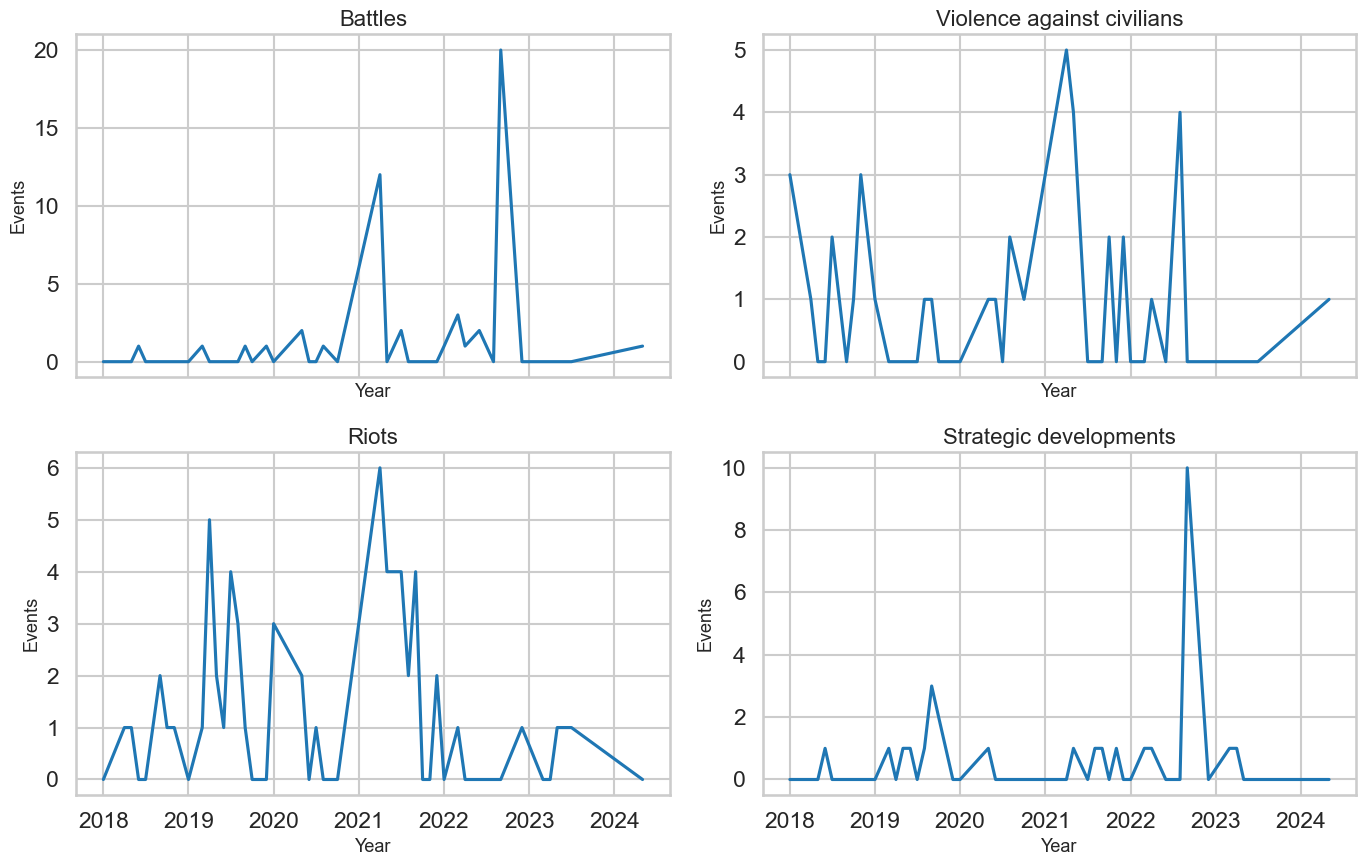

event_type,Battles,Violence against civilians,Riots,Strategic developments
event_month,,,,
2023-03-01,0,0,0,1
2023-04-01,0,0,0,1
2023-05-01,0,0,1,0
2023-07-01,0,0,1,0
2024-05-01,1,1,0,0


In [ ]:
event_types = [
    "Battles",
    "Violence against civilians",
    "Riots",
    "Strategic developments",
]

monthly_counts = (
    df_f[df_f["event_type"].isin(event_types)]
    .groupby(["event_month", "event_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=event_types)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, event_type in zip(axes, event_types):
    ax.plot(monthly_counts.index, monthly_counts[event_type], color="#1f77b4")
    ax.set_title(event_type)
    ax.set_xlabel("Year")
    ax.set_ylabel("Events")

plt.tight_layout()
plt.show()

monthly_counts.tail()


### 4) Pre-2023 vs post-2023 comparison

We compare event counts before 2023 to 2023–2025 to test for shifts in event types.


In [ ]:
df_f["period"] = df_f["event_date"].dt.year.map(
    lambda y: "Pre-2023" if y < 2023 else "Post-2023"
)

event_summary = (
    df_f[df_f["event_type"].isin(event_types)]
    .groupby(["period", "event_type"])
    .size()
    .reset_index(name="events")
    .pivot(index="event_type", columns="period", values="events")
    .fillna(0)
    .astype(int)
)

event_summary


period,Post-2023,Pre-2023
event_type,,
Battles,1,48
Riots,2,53
Strategic developments,2,27
Violence against civilians,1,36


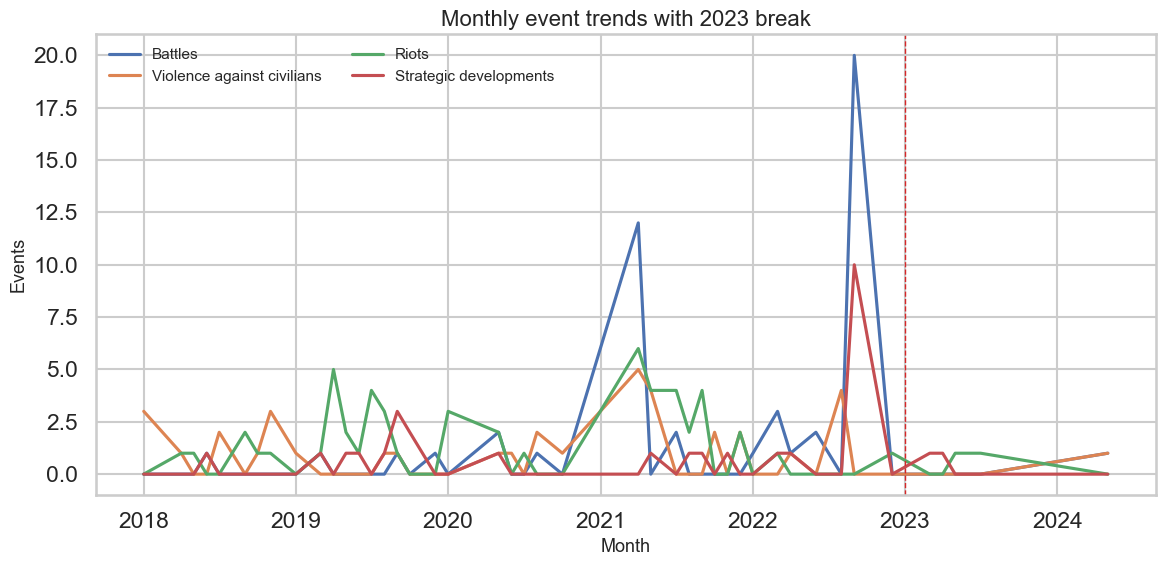

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for event_type in event_types:
    ax.plot(monthly_counts.index, monthly_counts[event_type], label=event_type)

ax.axvline(pd.Timestamp("2023-01-01"), color="#d62728", linestyle="--", linewidth=1)
ax.set_title("Monthly event trends with 2023 break")
ax.set_xlabel("Month")
ax.set_ylabel("Events")
ax.legend(ncol=2, frameon=False)

plt.tight_layout()
plt.show()


### 5) Actor categories

We classify ACLED actor names into broad categories relevant to your hypothesis (state forces, rioters, identity militias, civilians, unidentified armed groups).


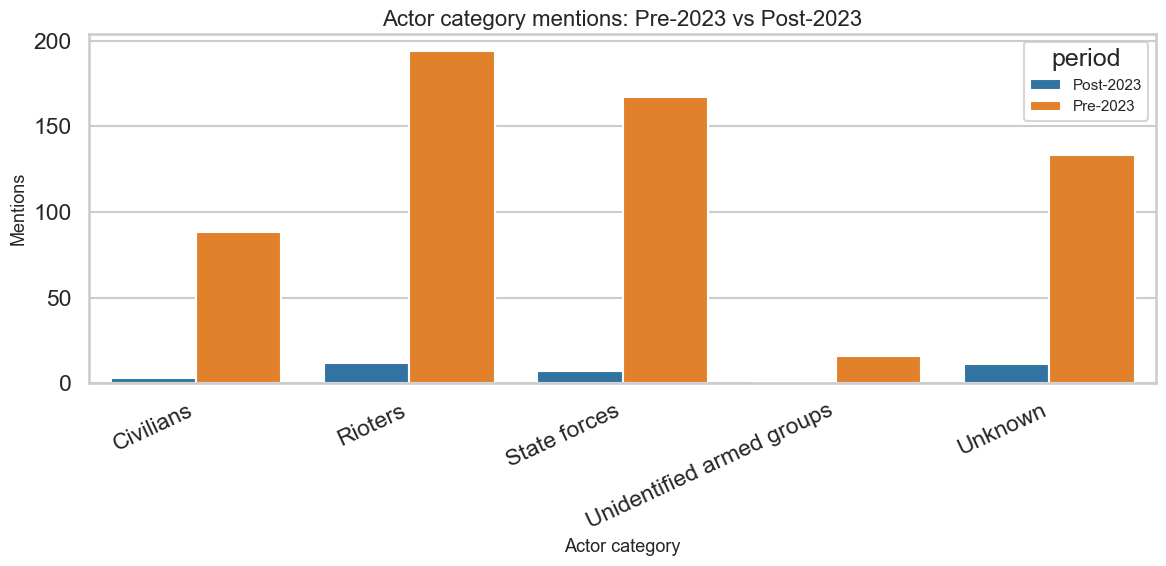

,period,actor_category,mentions
1,Post-2023,Rioters,12
4,Post-2023,Unknown,11
2,Post-2023,State forces,7
0,Post-2023,Civilians,3
3,Post-2023,Unidentified armed groups,1
6,Pre-2023,Rioters,194
7,Pre-2023,State forces,167
9,Pre-2023,Unknown,133
5,Pre-2023,Civilians,88
8,Pre-2023,Unidentified armed groups,16


In [ ]:
def classify_actor(actor_name: str) -> str:
    if pd.isna(actor_name):
        return "Unknown"

    actor = str(actor_name).lower()

    if any(keyword in actor for keyword in [
        "military forces",
        "police forces",
        "state forces",
        "border guards",
        "ministry of interior",
        "government of",
    ]):
        return "State forces"
    if "riot" in actor or "protest" in actor:
        return "Rioters"
    if "identity militia" in actor or "ethnic militia" in actor:
        return "Identity militias"
    if "civilians" in actor:
        return "Civilians"
    if "unidentified armed group" in actor or "unidentified" in actor:
        return "Unidentified armed groups"

    return "Other/Unknown"


df_f["actor1_cat"] = df_f["actor1"].apply(classify_actor)
df_f["actor2_cat"] = df_f["actor2"].apply(classify_actor)

actor_mentions = pd.concat(
    [
        df_f[["period", "actor1_cat"]].rename(columns={"actor1_cat": "actor_category"}),
        df_f[["period", "actor2_cat"]].rename(columns={"actor2_cat": "actor_category"}),
    ],
    ignore_index=True,
)

actor_counts = (
    actor_mentions.groupby(["period", "actor_category"]).size().reset_index(name="mentions")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=actor_counts,
    x="actor_category",
    y="mentions",
    hue="period",
    palette="tab10",
)
plt.title("Actor category mentions: Pre-2023 vs Post-2023")
plt.xlabel("Actor category")
plt.ylabel("Mentions")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

actor_counts.sort_values(["period", "mentions"], ascending=[True, False]).head(10)


### 6) Interaction analysis and highlighted actor pairs

We count ACLED interaction types (if present) and highlight interactions aligned with your hypothesis.


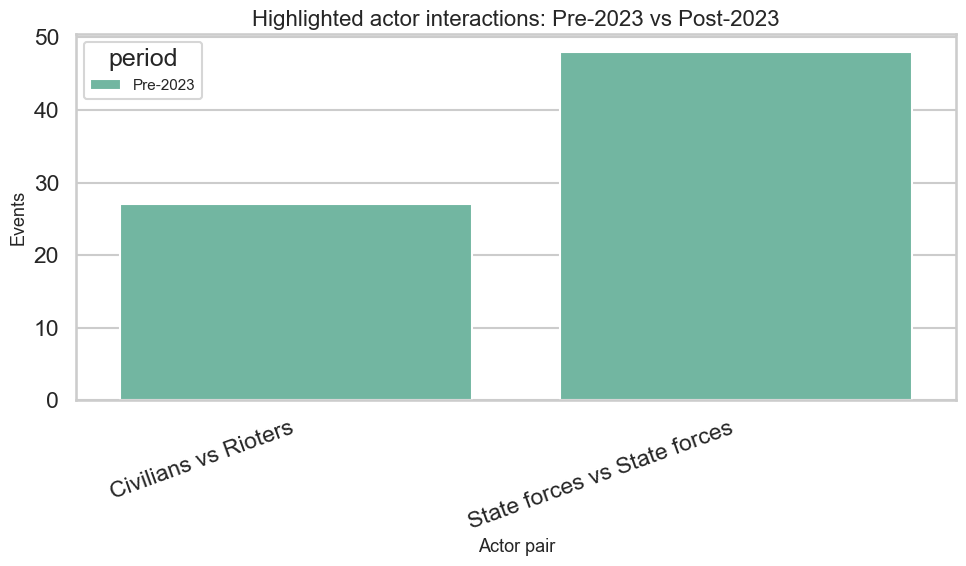

,period,actor_pair,events
1,Pre-2023,State forces vs State forces,48
0,Pre-2023,Civilians vs Rioters,27


In [ ]:
if "interaction" in df_f.columns:
    interaction_counts = df_f["interaction"].value_counts().sort_index()
    interaction_counts


def normalize_pair(actor_a: str, actor_b: str) -> str:
    return " vs ".join(sorted([actor_a, actor_b]))


df_f["actor_pair"] = df_f.apply(
    lambda row: normalize_pair(row["actor1_cat"], row["actor2_cat"]), axis=1
)

highlight_pairs = [
    "State forces vs State forces",
    "Civilians vs Rioters",
    "Civilians vs Civilians",
    "Identity militias vs Civilians",
    "Identity militias vs State forces",
]

pair_counts = (
    df_f[df_f["actor_pair"].isin(highlight_pairs)]
    .groupby(["period", "actor_pair"])
    .size()
    .reset_index(name="events")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pair_counts,
    x="actor_pair",
    y="events",
    hue="period",
    palette="Set2",
)
plt.title("Highlighted actor interactions: Pre-2023 vs Post-2023")
plt.xlabel("Actor pair")
plt.ylabel("Events")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

pair_counts.sort_values(["period", "events"], ascending=[True, False])
